In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/1"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第1章 深層学習革命 (The Deep Learning Revolution)
## 1.3 機械学習の略史：単層から深層へ (A Brief History of Machine Learning)

今日の深層学習の成功は、突然変異的に生まれたものではなく、半世紀以上にわたる数理モデルの探究、理論的限界との対峙、そして2度にわたる「AIの冬（AI Winter）」を乗り越えた歴史的進化の結実です。
本ノートブックでは、Bishop & Bishop (2024) 第1章 1.3節に基づき、ニューラルネットワークの歴史的展開をアルゴリズムと数理の両面から体系的に学びます：

1. **1.3.1 単層ネットワーク (Single-layer networks)**: 生物学的ニューロン、Rosenblattのパーセプトロン、Minsky & Papert によるXOR問題の証明と第1次AIの冬 (Figure 1.12 - 1.14)
2. **1.3.2 誤差逆伝播法 (Backpropagation)**: 多層パーセプトロン (MLP)、連鎖律による $O(W)$ 高速勾配計算、第2次AIの冬 (Figure 1.15)
3. **1.3.3 深層ネットワーク (Deep networks)**: 2012年以降の革命の三位一体（アルゴリズム・データ・GPU）、計算資源の爆発的成長 (Figure 1.16)


In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))

import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import setup_style, save_plot

setup_style()
print("環境セットアップ完了")


環境セットアップ完了


---
### 1.3.1 単層ネットワーク (Single-layer Networks)

#### 生物学的ニューロンから人工ニューロンへ (Figure 1.12)
脳の最小計算単位である神経細胞（ニューロン）は、樹状突起（Dendrites）で他のニューロンからのシナプス入力を集約し、細胞体（Soma）で電位が閾値を超えると発火（Fire）して、軸索（Axon）を通じて電気インパルス（活動電位）を出力します（Figure 1.12）。

これを数理モデル化したのが、ウォーレン・マカロックとウォルター・ピッツの**形式ニューロン（McCulloch-Pitts Neuron, 1943）**であり、それを学習可能な工学デバイスへと発展させたのがフランク・ローゼンブラットの**パーセプトロン（Perceptron, 1958, Figure 1.13）**です。


Figure saved successfully to: result/fig1_12_biological_neuron.png


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12491 (\N

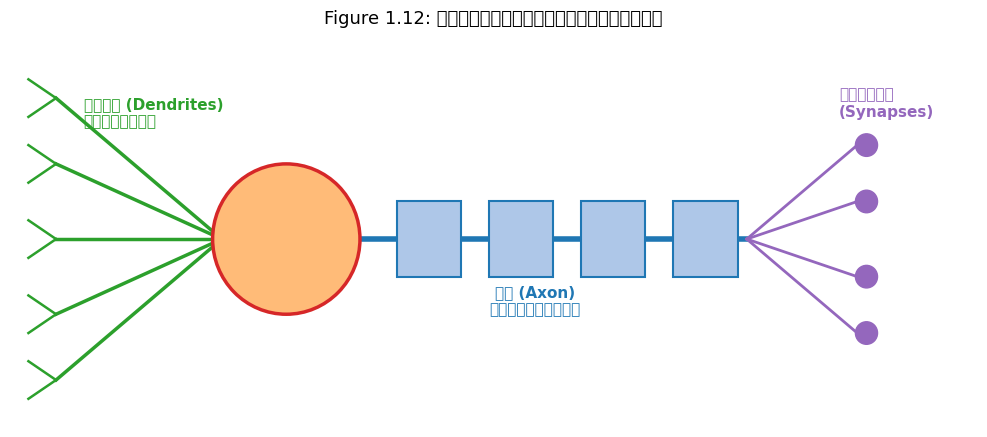

In [2]:
# Figure 1.12 再現: 生物学的ニューロンの模式図と活動電位伝達
fig, ax = plt.subplots(figsize=(10, 4.5))

# 細胞体 (Soma)
soma = plt.Circle((3, 2), 0.8, color='#ffbb78', ec='#d62728', lw=2.5, zorder=4)
ax.add_patch(soma)
ax.text(3, 2, "細胞体\n(Soma)", ha='center', va='center', fontweight='bold', fontsize=11)

# 樹状突起 (Dendrites)
dendrite_y = [0.5, 1.2, 2.0, 2.8, 3.5]
for dy in dendrite_y:
    ax.plot([0.5, 2.3], [dy, 2.0], color='#2ca02c', lw=2.5, zorder=2)
    ax.plot([0.2, 0.5], [dy - 0.2, dy], color='#2ca02c', lw=1.8, zorder=2)
    ax.plot([0.2, 0.5], [dy + 0.2, dy], color='#2ca02c', lw=1.8, zorder=2)
ax.text(0.8, 3.2, "樹状突起 (Dendrites)\nシナプス入力受容", color='#2ca02c', fontweight='bold')

# 軸索 (Axon)
ax.plot([3.8, 8.0], [2, 2], color='#1f77b4', lw=4.0, zorder=2)
# 髄鞘 (Myelin sheath)
for sx in [4.2, 5.2, 6.2, 7.2]:
    sheath = plt.Rectangle((sx, 1.6), 0.7, 0.8, facecolor='#aec7e8', edgecolor='#1f77b4', lw=1.5, zorder=3)
    ax.add_patch(sheath)
ax.text(5.7, 1.2, "軸索 (Axon)\nインパルス長距離伝導", color='#1f77b4', fontweight='bold', ha='center')

# 軸索末端 (Axon terminals)
terminal_y = [1.0, 1.6, 2.4, 3.0]
for ty in terminal_y:
    ax.plot([8.0, 9.2], [2.0, ty], color='#9467bd', lw=2.0, zorder=2)
    synapse = plt.Circle((9.3, ty), 0.12, color='#9467bd', zorder=4)
    ax.add_patch(synapse)
ax.text(9.0, 3.3, "シナプス結合\n(Synapses)", color='#9467bd', fontweight='bold')

ax.set_xlim([0, 10.5])
ax.set_ylim([0, 4.2])
ax.axis('off')
ax.set_title("Figure 1.12: 生物学的ニューロンの解剖学的構造と信号伝達", fontsize=13)

save_plot(fig, 'result/fig1_12_biological_neuron.png')
plt.show()


#### ローゼンブラットのパーセプトロンの数理 (Figure 1.13)
入力ベクトル $\mathbf{x} = (x_1, \dots, x_D)^T$ に対し、重み $\mathbf{w} = (w_1, \dots, w_D)^T$ とバイアス $w_0$ を用いて入力の加重和（活性化値 $a$）を計算します：
$$a = \sum_{i=1}^D w_i x_i + w_0 = \mathbf{w}^T \mathbf{x} + w_0$$

そして、階段型（ステップ型）非線形活性化関数 $f(a)$ を適用して二値分類出力を生成します：
$$y = f(a) = \begin{cases} +1 & (a \ge 0) \\ -1 & (a < 0) \end{cases} \tag{1.5}$$


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12475 (\N{KATAKANA LETTER SE}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12514 (\N{KATAKANA LETTER

Font 'default' does not have a glyph for '\u30a4' [U+30a4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30a2' [U+30a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30b9' [U+30b9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30d0' [U+30d0], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u30d0' [U+30d0], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30a4' [U+30a4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30a2' [U+30a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30b9' [U+30b9], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_13_perceptron_architecture.png


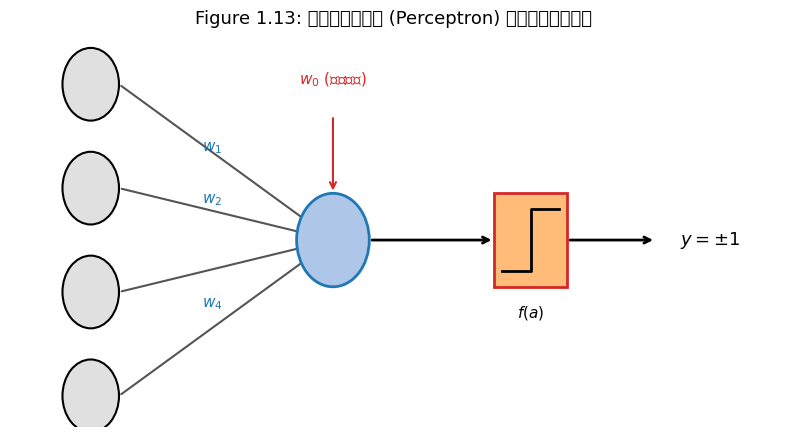

In [3]:
# Figure 1.13 再現: ローゼンブラットのパーセプトロンの計算グラフ
fig, ax = plt.subplots(figsize=(8, 4.5))

# 入力ノード
inputs = ['x_1', 'x_2', '\dots', 'x_D']
for i, name in enumerate(inputs):
    y_pos = 3.5 - i * 1.0
    circle = plt.Circle((1.5, y_pos), 0.35, color='#e0e0e0', ec='black', lw=1.5, zorder=4)
    ax.add_patch(circle)
    ax.text(1.5, y_pos, f"${name}$", ha='center', va='center', fontsize=12)
    # 重み矢印
    ax.annotate("", xy=(4.5, 2.0), xytext=(1.85, y_pos),
                arrowprops=dict(arrowstyle="->", lw=1.5, color='#555555'))
    if name != '\dots':
        ax.text(3.0, (y_pos + 2.0)/2 + 0.1, f"$w_{i+1}$", fontsize=11, color='#1f77b4', ha='center')

# バイアス
ax.text(4.5, 3.5, "$w_0$ (バイアス)", ha='center', fontsize=11, color='#d62728')
ax.annotate("", xy=(4.5, 2.45), xytext=(4.5, 3.2),
            arrowprops=dict(arrowstyle="->", lw=1.5, color='#d62728'))

# 加重和ノード
sum_node = plt.Circle((4.5, 2.0), 0.45, color='#aec7e8', ec='#1f77b4', lw=2.0, zorder=4)
ax.add_patch(sum_node)
ax.text(4.5, 2.0, "$\sum$", ha='center', va='center', fontsize=14, fontweight='bold')

# 活性化関数ノード
ax.annotate("", xy=(6.5, 2.0), xytext=(4.95, 2.0),
            arrowprops=dict(arrowstyle="->", lw=2.0, color='black'))
step_node = plt.Rectangle((6.5, 1.55), 0.9, 0.9, color='#ffbb78', ec='#d62728', lw=2.0, zorder=4)
ax.add_patch(step_node)
ax.plot([6.6, 6.95, 6.95, 7.3], [1.7, 1.7, 2.3, 2.3], color='black', lw=2.0, zorder=5)
ax.text(6.95, 1.25, "$f(a)$", ha='center', fontsize=11)

# 出力ノード
ax.annotate("", xy=(8.5, 2.0), xytext=(7.4, 2.0),
            arrowprops=dict(arrowstyle="->", lw=2.0, color='black'))
ax.text(8.8, 2.0, "$y = \pm 1$", ha='left', va='center', fontsize=13, fontweight='bold')

ax.set_xlim([0.5, 10.0])
ax.set_ylim([0.2, 4.0])
ax.axis('off')
ax.set_title("Figure 1.13: パーセプトロン (Perceptron) の数理モデル構造", fontsize=13)

save_plot(fig, 'result/fig1_13_perceptron_architecture.png')
plt.show()


#### Mark 1 Perceptron ハードウェア (Figure 1.14)
パーセプトロンは当初、ソフトウェアではなく専用のハードウェア計算機として実装されました。
1960年、コーネル航空研究所で完成した **Mark 1 Perceptron（Figure 1.14）** は、入力部に $20 \times 20 = 400$ ピクセルの硫化カドミウム光電池アレイ（カメラ）を備え、400個の調整可能重みは**モーター駆動の可変抵抗器（ポテンショメータ）**によって物理的に回転制御されていました。


Font 'default' does not have a glyph for '\u5149' [U+5149], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u96fb' [U+96fb], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6c60' [U+6c60], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30ab' [U+30ab], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30e1' [U+30e1], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u30f3' [U+30f3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30b7' [U+30b7], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30e7' [U+30e7], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30e1' [U+30e1], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_14_mark1_hardware.png


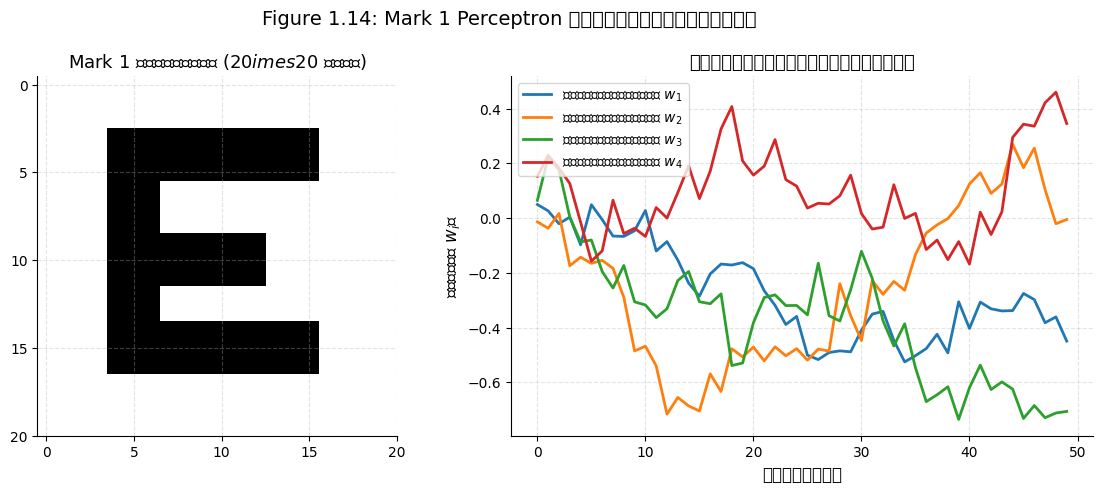

In [4]:
# Figure 1.14 再現: Mark 1 Perceptron のハードウェア構造模式図 (400光電池とモーター駆動ポテンショメータ)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左パネル: 20x20 光受容セルカメラアレイ (Cadmium-Sulfide Photocell Array)
grid = np.zeros((20, 20))
# アルファベット "E" の投影パターン
grid[3:17, 4:7] = 1.0
grid[3:6, 4:16] = 1.0
grid[9:12, 4:13] = 1.0
grid[14:17, 4:16] = 1.0

ax1.imshow(grid, cmap='binary', origin='upper')
ax1.set_title("Mark 1 光電池カメラアレイ ($20 \times 20$ ピクセル)")
ax1.set_xticks(np.arange(0, 21, 5))
ax1.set_yticks(np.arange(0, 21, 5))

# 右パネル: ポテンショメータ駆動による重み学習ダイナミクス
steps = np.arange(50)
np.random.seed(42)
weights_sim = np.cumsum(np.random.normal(0, 0.1, size=(50, 4)), axis=0)

for i in range(4):
    ax2.plot(steps, weights_sim[:, i], lw=2.0, label=f'モーター駆動ポテンショメータ $w_{i+1}$')

ax2.set_xlabel('学習反復ステップ')
ax2.set_ylabel('抵抗値（重み $w_i$）')
ax2.set_title('物理的可変抵抗器による重み更新ダイナミクス')
ax2.legend()

fig.suptitle("Figure 1.14: Mark 1 Perceptron の物理ハードウェアアーキテクチャ", fontsize=14)
save_plot(fig, 'result/fig1_14_mark1_hardware.png')
plt.show()


#### ミンスキー＆パパートによる死刑宣告：XOR問題と第1次AIの冬
1969年、マービン・ミンスキーとシーモア・パパートは著書『Perceptrons』において、単層パーセプトロンの致命的な限界を数学的に証明しました：
- パーセプトロンの決定境界は超平面 $\mathbf{w}^T \mathbf{x} + w_0 = 0$（2次元空間では1本の直線）に限られるため、**線形分離可能（Linearly Separable）な問題しか解けない**。
- 最も単純な論理演算の一つである **排他的論理和 (XOR)** すら解くことができない。

#### XORの数学的不能性証明
XORの真理値表：
- $(0, 0) \to 0$
- $(0, 1) \to 1$
- $(1, 0) \to 1$
- $(1, 1) \to 0$

もし重み $w_1, w_2$ とバイアス $b$ で分離できると仮定すると：
1. $0\cdot w_1 + 0\cdot w_2 + b < 0 \implies b < 0$
2. $0\cdot w_1 + 1\cdot w_2 + b \ge 0 \implies w_2 + b \ge 0$
3. $1\cdot w_1 + 0\cdot w_2 + b \ge 0 \implies w_1 + b \ge 0$
4. $1\cdot w_1 + 1\cdot w_2 + b < 0 \implies w_1 + w_2 + b < 0$

式2と式3を足すと: $w_1 + w_2 + 2b \ge 0$。
これに式1（$b < 0$）を代入すると: $w_1 + w_2 + b > w_1 + w_2 + 2b \ge 0 \implies w_1 + w_2 + b > 0$。
これは式4（$w_1 + w_2 + b < 0$）と**完全に矛盾**します。
この証明によりニューラルネット研究は「限界がある」と見なされ、資金提供が途絶える**第1次AIの冬（First AI Winter, 1970年代）**が到来しました。


---
### 1.3.2 誤差逆伝播法 (Backpropagation) と多層パーセプトロン

#### 隠れ層による特徴空間の非線形歪曲 (Figure 1.15)
XOR問題の解決策は、入力層と出力層の間に**隠れ層（Hidden Layer）**を導入した**多層パーセプトロン（MLP: Multilayer Perceptron）**です：
$$a_j = \sum_{i=1}^D w_{ji}^{(1)} x_i + w_{j0}^{(1)} \tag{1.5}$$
$$z_j = h(a_j) \tag{1.6}$$
$$y_k = \sum_{j=1}^M w_{kj}^{(2)} z_j + w_{k0}^{(2)}$$

ここで $h(\cdot)$ は滑らかな非線形活性化関数（ロジスティックシグモイドや $\tanh$、ReLU）です。
隠れユニット $z_j$ は、入力空間を非線形に変形（空間を折り曲げる）し、元の空間では線形分離不可能だったデータを、隠れ空間において**線形分離可能な配置へと射影**します。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12493 (\N{KATAKANA LETTER NE}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12527 (\N{KATAKANA LETTER WA}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
Font 'default' does not have a glyph for '\u5165' [U+5165], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u529b' [U+529b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5c64' [U+5c64], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u96a0' [U+96a0], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u308c' [U+308c], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u5c64' [U+5c64], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u51fa' [U+51fa], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u529b' [U+529b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5c64' [U+5c64], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_15_two_layer_mlp.png


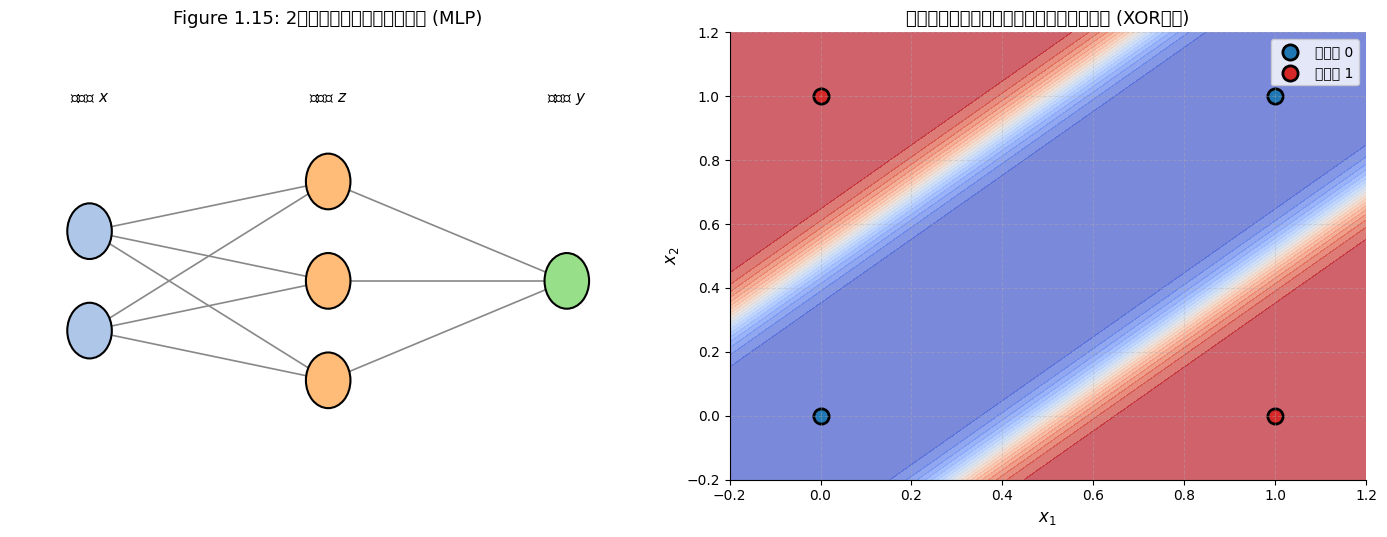

In [5]:
# Figure 1.15 再現: 2層多層パーセプトロン (MLP) の構造と隠れ層によるXORの解決
fig, (ax_arch, ax_xor) = plt.subplots(1, 2, figsize=(14, 5.5))

# 左パネル: 2層ネットワークのアーキテクチャ図
layer_sizes = [2, 3, 1]
layer_names = ['入力層 $x$', '隠れ層 $z$', '出力層 $y$']
v_spacing = 1.0

for l_idx, (l_size, l_name) in enumerate(zip(layer_sizes, layer_names)):
    x_pos = l_idx * 3.0
    for n_idx in range(l_size):
        y_pos = (l_size - 1) * -0.5 * v_spacing + n_idx * v_spacing
        color = '#aec7e8' if l_idx==0 else ('#ffbb78' if l_idx==1 else '#98df8a')
        circle = plt.Circle((x_pos, y_pos), 0.28, color=color, ec='black', lw=1.5, zorder=4)
        ax_arch.add_patch(circle)
        
        # 前層との結合線
        if l_idx > 0:
            prev_size = layer_sizes[l_idx - 1]
            prev_x = (l_idx - 1) * 3.0
            for p_idx in range(prev_size):
                prev_y = (prev_size - 1) * -0.5 * v_spacing + p_idx * v_spacing
                ax_arch.plot([prev_x, x_pos], [prev_y, y_pos], color='#888888', lw=1.2, zorder=2)
    ax_arch.text(x_pos, 1.8, l_name, ha='center', fontweight='bold', fontsize=11)

ax_arch.set_xlim([-1.0, 7.0])
ax_arch.set_ylim([-2.0, 2.5])
ax_arch.axis('off')
ax_arch.set_title("Figure 1.15: 2層ニューラルネットワーク (MLP)")

# 右パネル: 隠れユニットによるXOR空間の線形分離化シミュレーション
# XORの4点
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# 2層MLPによる決定境界
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 100), np.linspace(-0.2, 1.2, 100))
# 隠れ層による特徴変換
h1 = 1.0 / (1.0 + np.exp(-(20 * xx - 20 * yy - 10)))
h2 = 1.0 / (1.0 + np.exp(-(-20 * xx + 20 * yy - 10)))
out = h1 + h2

ax_xor.contourf(xx, yy, out, levels=20, cmap='coolwarm', alpha=0.7)
ax_xor.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], color='#1f77b4', s=120, edgecolors='black', lw=2, label='クラス 0')
ax_xor.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], color='#d62728', s=120, edgecolors='black', lw=2, label='クラス 1')
ax_xor.set_title("多層パーセプトロンによる非線形決定境界 (XOR解決)")
ax_xor.set_xlabel('$x_1$')
ax_xor.set_ylabel('$x_2$')
ax_xor.legend(loc='upper right')

save_plot(fig, 'result/fig1_15_two_layer_mlp.png')
plt.show()


#### 誤差逆伝播法の本質的威力：計算量 $O(W)$
隠れ層を持つネットワークでは、重みが多段に連なるため、中間層の重みをどのように更新すべきか（Credit Assignment Problem）が長年の難問でした。
1986年、ラメルハート、ヒントン、ウィリアムズら（および独立にウェルボス 1974）によって**誤差逆伝播法（Error Backpropagation）**が脚光を浴びました：
- **微積分の連鎖律（Chain Rule）**を適用することで、出力層から入力層へ向けて誤差シグナル $\delta$ を逆向きに伝播。
- ネットワーク全体のパラメータ数を $W$ としたとき、全パラメータに関する勾配ベクトル $\nabla_{\mathbf{w}} E$ を**わずか $O(W)$ の計算量**（フォワードプロパゲーションの定数倍）で同時に解析計算できる。
- 数値微分（有限差分）では $O(W^2)$ かかる計算を劇的に効率化し、多層ネットワークの勾配降下法による学習を現実のものとしました（第8章で詳述）。

#### 第2次AIの冬 (1990年代)
しかし、MLPもすぐに限界に直面しました：
1. **勾配消失問題 (Vanishing Gradient)**: 層を4層、5層と深くすると、逆伝播に伴いシグモイド関数の導関数（最大値0.25）が連乗され、入力層付近の勾配が指数関数的に消失して学習が停止する。
2. **過学習 (Over-fitting)**: パラメータ数に対して訓練データが少なすぎたため、汎化性能が低下。
3. **計算資源の不足**: 1990年代のCPU性能では、実用的な大規模データを訓練できなかった。
結果として、大域的最適解が保証されるサポートベクトルマシン（SVM）やランダムフォレストに主役を奪われ、**第2次AIの冬**に入りました。


---
### 1.3.3 深層ネットワーク (Deep Networks) と計算量の爆発

#### 2012年のブレイクスルーと深層学習の三位一体
2012年、世界最高峰の画像認識コンペ（ILSVRC）において、ジェフリー・ヒントン率いるトロント大学のチームが開発した **AlexNet** が、2位以下に圧倒的な大差（エラー率を26%から15%へ急減）をつけて優勝し、第3次AIブーム（深層学習革命）が幕を開けました。

深層学習を可能にした3大要因：
1. **アルゴリズムの革新**:
   - 活性化関数 **ReLU (Rectified Linear Unit)**: 正の領域で微分値が常に $1$ であり、勾配消失問題を劇的に緩和。
   - **Dropout**: 過学習を抑制する強力な正則化。
   - **残差接続 (ResNet, 2015)**: 100層を超える超多層ネットワークの安定学習を実現。
2. **大規模データセット**:
   - インターネットの普及により、数百万枚のラベル付き画像（ImageNet）や数兆語のテキストデータが利用可能に。
3. **並列計算資源 (GPU/TPU)**:
   - 画像処理用プロセッサ（NVIDIA GPU）を汎用並列計算（GPGPU / CUDA）に応用し、行列積計算を数百倍に高速化。

#### Figure 1.16: 最先端AIモデルの学習計算量の二段階指数関数成長
Figure 1.16 は、最先端ニューラルネットワークの訓練に必要な総計算量（**Petaflop/s-days**: 毎秒 $10^{15}$ 回の浮動小数点演算を1日続けた仕事量）の歴史的推移を示しています。

驚くべきことに、計算量の推移には明確な**2つの指数関数成長期（Two Distinct Phases）**が存在します：
- **第1期（1959年 〜 2012年）**:
  コンピュータのハードウェア進化（ムーアの法則）に沿って、訓練計算量は**約2年で倍増**。
- **第2期（2012年 〜 現代: 深層学習時代）**:
  GPUクラスタや専用アクセラレータの大規模並列化により、訓練計算量は**わずか約3.4ヶ月で倍増**（年間約10倍の成長）。2012年のAlexNetから2018年のAlphaGo Zeroまでのわずか6年間で、計算量は**30万倍以上**に爆発しました。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 30330 (\N{CJK UNIFIED IDEOGRAPH-767A}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 32244 (\N

Figure saved successfully to: result/fig1_16_compute_growth.png


/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30330 (\N{CJK UNIFIED IDEOGRAPH-767A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/I

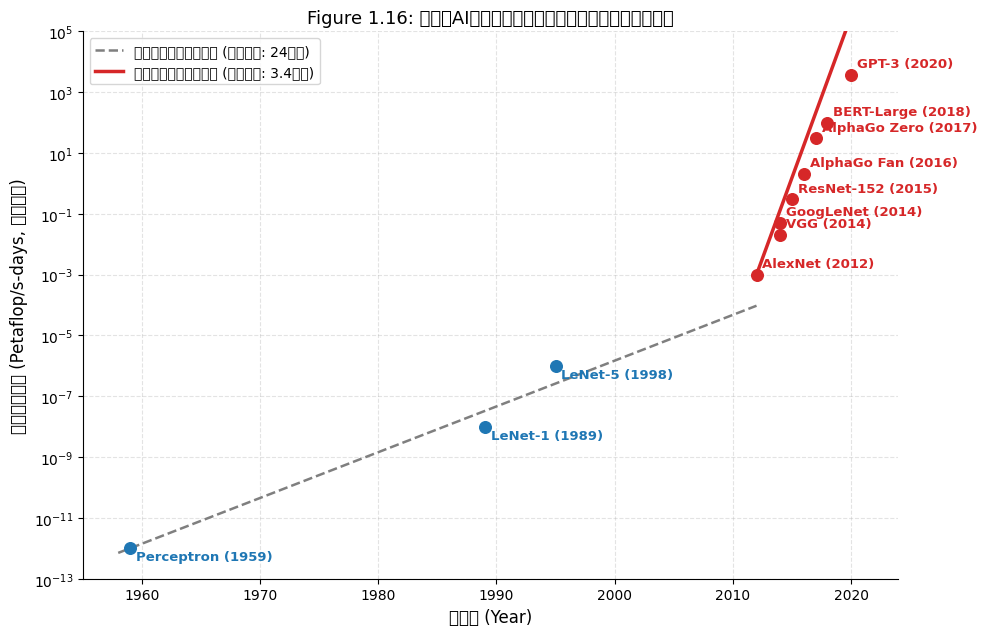

In [6]:
# Figure 1.16 再現: 最先端AIモデルの訓練計算量推移 (Petaflop/s-days, OpenAI 2018データ準拠)
fig, ax = plt.subplots(figsize=(10, 6.5))

# 代表的歴史的モデルと推定計算量 (Petaflop/s-days)
models_data = [
    # 年, Petaflop/s-days, モデル名, 位相(0: プレ深層学習, 1: 深層学習時代)
    (1959, 1e-12, 'Perceptron (1959)', 0),
    (1989, 1e-8, 'LeNet-1 (1989)', 0),
    (1995, 1e-6, 'LeNet-5 (1998)', 0),
    (2012, 1e-3, 'AlexNet (2012)', 1),
    (2014, 2e-2, 'VGG (2014)', 1),
    (2014, 5e-2, 'GoogLeNet (2014)', 1),
    (2015, 3e-1, 'ResNet-152 (2015)', 1),
    (2016, 2.0, 'AlphaGo Fan (2016)', 1),
    (2017, 30.0, 'AlphaGo Zero (2017)', 1),
    (2018, 100.0, 'BERT-Large (2018)', 1),
    (2020, 3640.0, 'GPT-3 (2020)', 1)
]

years = [d[0] for d in models_data]
computes = [d[1] for d in models_data]

# 第1期トレンド線 (ムーアの法則: 2年倍増)
years_p1 = np.linspace(1958, 2012, 100)
# 1959年に 1e-12, 2年で2倍
p1_trend = 1e-12 * (2 ** ((years_p1 - 1959) / 2.0))
ax.plot(years_p1, p1_trend, linestyle='--', color='#7f7f7f', lw=1.8, label='ムーアの法則トレンド (倍増期間: 24ヶ月)')

# 第2期トレンド線 (深層学習時代: 3.4ヶ月倍増)
years_p2 = np.linspace(2012, 2021, 100)
# 2012年に 1e-3, 3.4ヶ月 (0.283年) で2倍
p2_trend = 1e-3 * (2 ** ((years_p2 - 2012) / (3.4 / 12.0)))
ax.plot(years_p2, p2_trend, linestyle='-', color='#d62728', lw=2.5, label='深層学習時代トレンド (倍増期間: 3.4ヶ月)')

# データ点プロット
for yr, comp, name, phase in models_data:
    color = '#1f77b4' if phase == 0 else '#d62728'
    ax.scatter(yr, comp, color=color, s=70, zorder=5)
    # ラベル位置調整
    offset_x = 0.5
    offset_y = 1.8 if phase == 1 else 0.4
    ax.text(yr + offset_x, comp * offset_y, name, fontsize=9.5, fontweight='bold', color=color)

ax.set_yscale('log')
ax.set_xlabel('発表年 (Year)')
ax.set_ylabel('訓練総計算量 (Petaflop/s-days, 対数目盛)')
ax.set_title('Figure 1.16: 最先端AIモデルの訓練計算量の二段階指数関数成長')
ax.set_xlim([1955, 2024])
ax.set_ylim([1e-13, 1e5])
ax.legend(loc='upper left')

save_plot(fig, 'result/fig1_16_compute_growth.png')
plt.show()


---
### まとめ

第1章では、深層学習がもたらした革命的成果から、多項式回帰を通じた過学習と正則化の基本原理、そして半世紀にわたる歴史的進化を概観しました。
次章以降では、この深層学習の全体系を支える数学的基礎へと足を踏み入れます：

- **第2章 確率の基礎 (Probabilities)**: 不確実性を扱うための確率規則、正規分布、情報理論
- **第3章 基本分布 (Standard Distributions)**: ガウス分布の幾何学、指数型分布族
- **第4章・第5章 単層ネットワーク (Single-layer Networks)**: 回帰と分類の厳密な数理
- **第6章〜第9章 深層学習のコア**: 多層化、勾配降下法、誤差逆伝播法、正則化
- **第10章〜第20章 現代のアーキテクチャ**: CNN、Transformers、GNN、拡散モデルなど
